In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Environment Check ---")
print(f" PyTorch version : {torch.__version__}")
print(f" CUDA available  : {torch.cuda.is_available()}")
print(f" Using device    : {device}")
print("-------------------------")

--- Environment Check ---
 PyTorch version : 2.1.0+cpu
 CUDA available  : False
 Using device    : cpu
-------------------------


In [3]:
TRAIN_DIR      = "../datasets/train"
VAL_DIR        = "../datasets/val"
               
IMG_SIZE       = 224
BATCH_SIZE     = 32
EXTRA_EPOCHS   = 20
CONF_THRESHOLD = 0.80

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

 Using device: cpu


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_test_transforms)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f" Classes       : {CLASS_NAMES}")
print(f" Train samples : {len(train_dataset)}")
print(f" Val samples   : {len(val_dataset)}")

 Classes       : ['Drought', 'Healthy', 'Pest']
 Train samples : 1920
 Val samples   : 480


In [5]:
print(" Loading local ImageNet weights from manually moved file")

local_weight_path = "../model/resnet18-f37072fd.pth"

model = models.resnet18(weights=None)

model.load_state_dict(torch.load(local_weight_path, map_location=device))

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
print(" Fix 1: Unfroze layer3, layer4, fc")

criterion = nn.CrossEntropyLoss()
print(" Fix 2: Standard CrossEntropyLoss applied")

optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
])
print(" Fix 3: Layered optimizer ready")
print("\n All fixes applied — ready to train!")

 Loading local ImageNet weights from manually moved file
 Fix 1: Unfroze layer3, layer4, fc
 Fix 2: Standard CrossEntropyLoss applied
 Fix 3: Layered optimizer ready

 All fixes applied — ready to train!


In [6]:
best_val_acc = 0.0   

for epoch in range(EXTRA_EPOCHS):
    print(f"Epoch {epoch+1}/{EXTRA_EPOCHS}")
    print("-" * 30)
    start_time = time.time()

    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train   = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc  = correct_train / total_train

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc  = correct_val / total_val
    elapsed        = time.time() - start_time

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"Time: {elapsed:.2f}s")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save({
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names"         : CLASS_NAMES,
            "num_classes"         : NUM_CLASSES,
            "epoch"               : epoch + 1,
        }, "../model/final-resnet18-model.pth") 
        print(f"   New best saved! Val Acc: {best_val_acc:.4f}")
    print()

print(" Training complete!")

Epoch 1/20
------------------------------
Train Loss: 0.3112 | Train Acc: 0.8786
Val Loss:   0.1594 | Val Acc:   0.9354
Time: 369.12s
   New best saved! Val Acc: 0.9354

Epoch 2/20
------------------------------
Train Loss: 0.1317 | Train Acc: 0.9552
Val Loss:   0.0994 | Val Acc:   0.9729
Time: 370.65s
   New best saved! Val Acc: 0.9729

Epoch 3/20
------------------------------
Train Loss: 0.0877 | Train Acc: 0.9708
Val Loss:   0.0849 | Val Acc:   0.9646
Time: 398.55s

Epoch 4/20
------------------------------
Train Loss: 0.0692 | Train Acc: 0.9781
Val Loss:   0.0749 | Val Acc:   0.9729
Time: 379.27s

Epoch 5/20
------------------------------
Train Loss: 0.0693 | Train Acc: 0.9786
Val Loss:   0.1298 | Val Acc:   0.9583
Time: 371.39s

Epoch 6/20
------------------------------
Train Loss: 0.0598 | Train Acc: 0.9766
Val Loss:   0.1092 | Val Acc:   0.9729
Time: 383.02s

Epoch 7/20
------------------------------
Train Loss: 0.0488 | Train Acc: 0.9839
Val Loss:   0.1462 | Val Acc:   0.9729


 Loading the BEST saved model for evaluation...
 Running validation images through the model...

 Final Best Accuracy: 98.33%

--- Classification Report ---
              precision    recall  f1-score   support

     Drought       0.98      1.00      0.99       160
     Healthy       0.98      0.97      0.97       160
        Pest       0.99      0.98      0.98       160

    accuracy                           0.98       480
   macro avg       0.98      0.98      0.98       480
weighted avg       0.98      0.98      0.98       480



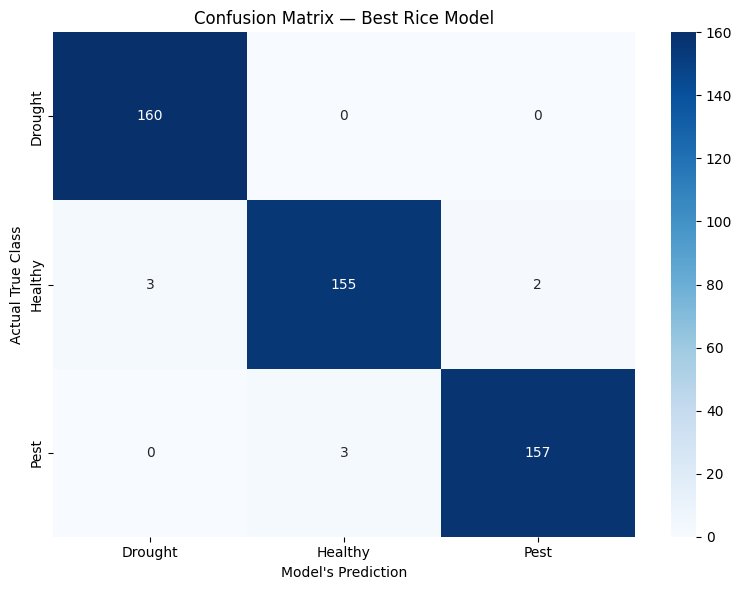


 Specific Class Confusions:
--- Healthy vs Pest ---
   Healthy → wrongly Pest    : 3  (target: <30)
   Pest    → wrongly Healthy : 2  (target: <15)

--- Drought vs Pest ---
   Drought → wrongly Pest    : 0
   Pest    → wrongly Drought : 3

--- Drought vs Healthy ---
   Drought → wrongly Healthy : 0
   Healthy → wrongly Drought : 0


In [8]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print(" Loading the BEST saved model for evaluation...")
checkpoint = torch.load("../model/final-resnet18-model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds  = []
all_labels = []

print(" Running validation images through the model...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = model(inputs)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"\n Final Best Accuracy: {test_acc*100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Best Rice Model")
plt.ylabel("Actual True Class")
plt.xlabel("Model's Prediction")
plt.tight_layout()
plt.show()

print("\n Specific Class Confusions:")

print("--- Healthy vs Pest ---")
print(f"   Healthy → wrongly Pest    : {cm[2][1]}  (target: <30)")
print(f"   Pest    → wrongly Healthy : {cm[1][2]}  (target: <15)")

print("\n--- Drought vs Pest ---")
print(f"   Drought → wrongly Pest    : {cm[0][1]}")
print(f"   Pest    → wrongly Drought : {cm[1][0]}")

print("\n--- Drought vs Healthy ---")
print(f"   Drought → wrongly Healthy : {cm[0][2]}")
print(f"   Healthy → wrongly Drought : {cm[2][0]}")